In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

data = './inventory_demand_forecasting.csv'
df = pd.read_csv(data)

# Inspect the data
---
## Conduct EDA on the Data
What are the details of the dataset?<br>
When was the start and end of the data?<br>
what's the higherst demand? What's the lowest?<br>

In [2]:
df.head(10)

,date,product_id,category,price,promotion,stock,demand
0,2023-01-01,A,Electronics,116,1,121,95
1,2023-01-01,B,Grocery,126,0,149,97
2,2023-01-01,C,Clothing,62,0,307,45
3,2023-01-01,D,Home,30,0,210,22
4,2023-01-01,E,Sports,98,0,98,71
5,2023-01-02,A,Electronics,199,0,495,85
6,2023-01-02,B,Grocery,117,0,104,66
7,2023-01-02,C,Clothing,82,0,216,74
8,2023-01-02,D,Home,69,1,63,50
9,2023-01-02,E,Sports,101,0,416,82


In [3]:
print(df.shape)
print(df.describe(include='all'))

(3650, 7)
              date product_id     category        price    promotion  \
count         3650       3650         3650  3650.000000  3650.000000   
unique         730          5            5          NaN          NaN   
top     2023-01-01          A  Electronics          NaN          NaN   
freq             5        730          730          NaN          NaN   
mean           NaN        NaN          NaN   104.267945     0.199178   
std            NaN        NaN          NaN    55.590559     0.399437   
min            NaN        NaN          NaN    10.000000     0.000000   
25%            NaN        NaN          NaN    54.000000     0.000000   
50%            NaN        NaN          NaN   105.000000     0.000000   
75%            NaN        NaN          NaN   153.000000     0.000000   
max            NaN        NaN          NaN   199.000000     1.000000   

              stock       demand  
count   3650.000000  3650.000000  
unique          NaN          NaN  
top             NaN 

In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        3650 non-null   object
 1   product_id  3650 non-null   object
 2   category    3650 non-null   object
 3   price       3650 non-null   int64 
 4   promotion   3650 non-null   int64 
 5   stock       3650 non-null   int64 
 6   demand      3650 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 199.7+ KB
None


In [5]:
print(df.dtypes)
print(df[['product_id', 'category']].value_counts())

date          object
product_id    object
category      object
price          int64
promotion      int64
stock          int64
demand         int64
dtype: object
product_id  category   
A           Electronics    730
B           Grocery        730
C           Clothing       730
D           Home           730
E           Sports         730
Name: count, dtype: int64


In [6]:
promotion_counts = df.promotion.value_counts()
print(promotion_counts)

promotion
0    2923
1     727
Name: count, dtype: int64


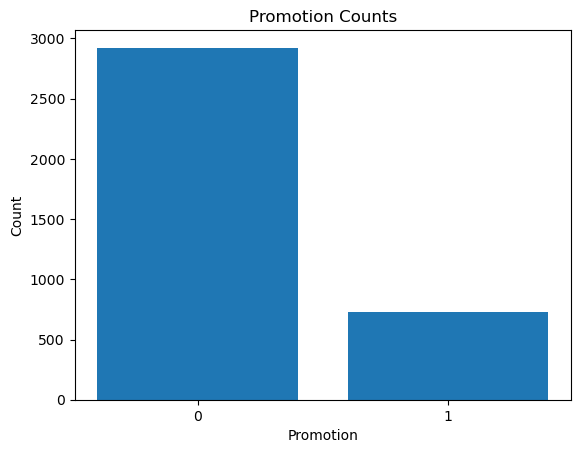

<Figure size 640x480 with 0 Axes>

In [7]:
plt.bar(promotion_counts.index.astype(str), promotion_counts.values)
plt.title("Promotion Counts")
plt.xlabel("Promotion")
plt.ylabel("Count")
plt.show()
plt.clf()

In [8]:
temp_df = df[['date', 'demand']].copy()
temp_df.date = pd.to_datetime(temp_df.date)
# print(temp_df.dtypes)
agg_temp_df = temp_df.groupby('date', as_index=False).demand.sum()
agg_temp_df = agg_temp_df.set_index('date')
monthly_agg_df = agg_temp_df.resample('ME').mean().reset_index()
print(monthly_agg_df)

         date      demand
0  2023-01-31  369.903226
1  2023-02-28  412.428571
2  2023-03-31  398.935484
3  2023-04-30  451.800000
4  2023-05-31  420.000000
5  2023-06-30  372.600000
6  2023-07-31  323.000000
7  2023-08-31  268.838710
8  2023-09-30  253.600000
9  2023-10-31  253.096774
10 2023-11-30  289.466667
11 2023-12-31  343.806452
12 2024-01-31  397.225806
13 2024-02-29  422.862069
14 2024-03-31  478.967742
15 2024-04-30  472.733333
16 2024-05-31  444.000000
17 2024-06-30  386.566667
18 2024-07-31  338.000000
19 2024-08-31  298.516129
20 2024-09-30  283.100000
21 2024-10-31  276.806452
22 2024-11-30  317.466667
23 2024-12-31  341.833333


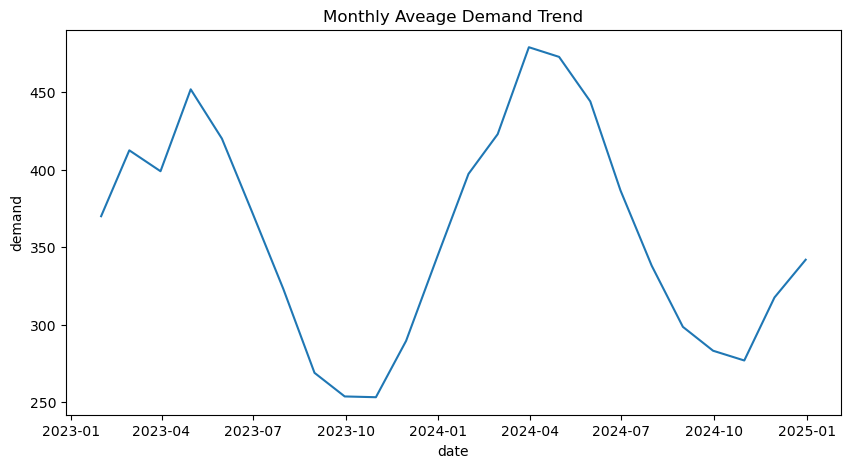

<Figure size 640x480 with 0 Axes>

In [9]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_agg_df, x='date', y='demand')
plt.title("Monthly Aveage Demand Trend")
plt.show()
plt.clf()

# Normalise the data

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [10]:
df = df.drop(columns=('category'))
df = pd.get_dummies(df, columns=['product_id'], drop_first=True)

In [15]:
print(df.head())
print(df.dtypes)

         date  price  promotion  stock  demand  product_id_B  product_id_C  \
0  2023-01-01    116          1    121      95         False         False   
1  2023-01-01    126          0    149      97          True         False   
2  2023-01-01     62          0    307      45         False          True   
3  2023-01-01     30          0    210      22         False         False   
4  2023-01-01     98          0     98      71         False         False   

   product_id_D  product_id_E  
0         False         False  
1         False         False  
2         False         False  
3          True         False  
4         False          True  
date            object
price            int64
promotion        int64
stock            int64
demand           int64
product_id_B      bool
product_id_C      bool
product_id_D      bool
product_id_E      bool
dtype: object


In [16]:
df['date'] = pd.to_datetime(df['date'])

df['month'] = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [18]:
print(df.head(10))
print(df.dtypes)

        date  price  promotion  stock  demand  product_id_B  product_id_C  \
0 2023-01-01    116          1    121      95         False         False   
1 2023-01-01    126          0    149      97          True         False   
2 2023-01-01     62          0    307      45         False          True   
3 2023-01-01     30          0    210      22         False         False   
4 2023-01-01     98          0     98      71         False         False   
5 2023-01-02    199          0    495      85         False         False   
6 2023-01-02    117          0    104      66          True         False   
7 2023-01-02     82          0    216      74         False          True   
8 2023-01-02     69          1     63      50         False         False   
9 2023-01-02    101          0    416      82         False         False   

   product_id_D  product_id_E  month  day_of_week  is_weekend  
0         False         False      1            6           1  
1         False         

In [19]:
X = df.drop(columns=['date', 'demand'])
y = df.demand

In [21]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [24]:
print(X)

[[ 0.21107293  2.00515155 -1.1755436  ... -1.59965875  1.49743809
   1.57886762]
 [ 0.39098424 -0.49871542 -0.96111794 ... -1.59965875  1.49743809
   1.57886762]
 [-0.76044813 -0.49871542  0.24885546 ... -1.59965875  1.49743809
   1.57886762]
 ...
 [ 0.37299311 -0.49871542 -1.08364689 ...  1.59250321 -1.49743809
  -0.63336532]
 [-0.52656343 -0.49871542 -0.12638945 ...  1.59250321 -1.49743809
  -0.63336532]
 [ 0.75080686 -0.49871542 -1.31338867 ...  1.59250321 -1.49743809
  -0.63336532]]


# Split training and testing data
---
The data would need splitting between features and target (*X and y*)<br>
Then import the necessary libraries to split the data into training and testing set

In [25]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Train the Model
---
I will be testing a single model before I create a pipeline as a personal preference.

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
lr = LinearRegression()
model = lr.fit(x_train, y_train)

# Assess the Model
---

In [32]:
rom sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [33]:
y_pred = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2 Score): {r2:.2f}")

Mean Absolute Error (MAE): 25.93
Root Mean Squared Error (RMSE): 31.74
R-squared (R2 Score): 0.17


# Implement Machine learning workflow

# Build ML Pipeline